# <b><font color='teal'>Homework 19</font></b>

In [5]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
# Загрузите файл df_cars.pkl
from pathlib import Path

# Работает и при запуске из корня проекта, и из папки DZ_python_DA
candidates = [Path('data/df_cars.pkl'), Path('../data/df_cars.pkl')]
for p in candidates:
    if p.exists():
        cars = pd.read_pickle(p)
        break
else:
    raise FileNotFoundError('Не найден data/df_cars.pkl (проверены пути data/ и ../data/)')

# Выведите первые 5 строк датафрейма
display(cars.head())

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,...,Brand,Model,Mileage_num,Mileage_units,Engine_num,Engine_units,Power_num,Power_units,New_Price_num,New_Price_units
0,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,...,Maruti,WagonR,35.4578,kmpl,998.0,CC,58.16,bhp,NaN,NaN
1,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,...,Hyundai,Creta1.6,19.6700,kmpl,1582.0,CC,126.20,bhp,NaN,NaN
2,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,...,Honda,JazzV,18.2000,kmpl,1199.0,CC,88.70,bhp,8.61,Lakh
3,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,...,Maruti,ErtigaVDI,20.7700,kmpl,1248.0,CC,88.76,bhp,NaN,NaN
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,...,Audi,A4New,15.2000,kmpl,1968.0,CC,140.80,bhp,NaN,NaN


##### <b><font color='teal'>Задание 1</font></b>
Повторите первичный анализ датасета used_cars_data после всех преобразований, сделанных на уроке. Определите, типы каких столбцов теперь можно изменить. Сделайте это.

In [ ]:
# С помощью метода info посмотрите на данные
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           7253 non-null   object 
 1   Year               7253 non-null   int64  
 2   Kilometers_Driven  7253 non-null   int64  
 3   Fuel_Type          7253 non-null   object 
 4   Transmission       7253 non-null   object 
 5   Owner_Type         7253 non-null   object 
 6   Mileage            7251 non-null   object 
 7   Engine             7207 non-null   object 
 8   Power              7207 non-null   object 
 9   Seats              7230 non-null   float64
 10  New_Price          1006 non-null   object 
 11  Price              6019 non-null   float64
 12  Car_Age            7253 non-null   int64  
 13  Brand              7253 non-null   object 
 14  Model              7252 non-null   object 
 15  Mileage_num        7253 non-null   float64
 16  Mileage_units      7251 

In [ ]:
# Измените тип данных столбцов, которые нужно/можно изменить с помощью метода astype
# Проверка после преобразований с лекции: есть ли столбцы, которые еще можно привести через astype
obj_cols = cars.select_dtypes(include='object').columns.tolist()

# Ищем object-столбцы, которые полностью числовые по содержимому
numeric_like_cols = [
    col for col in obj_cols
    if pd.to_numeric(cars[col], errors='coerce').notna().sum() == cars[col].notna().sum()
]

if numeric_like_cols:
    cars[numeric_like_cols] = cars[numeric_like_cols].apply(pd.to_numeric, errors='coerce')
    print('Преобразованы в числовой тип:', numeric_like_cols)
else:
    print('Дополнительные преобразования astype/pd.to_numeric не требуются: типы уже корректны.')

cars.info()

Дополнительные преобразования astype/pd.to_numeric не требуются: типы уже корректны.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Location           7253 non-null   object 
 1   Year               7253 non-null   int64  
 2   Kilometers_Driven  7253 non-null   int64  
 3   Fuel_Type          7253 non-null   object 
 4   Transmission       7253 non-null   object 
 5   Owner_Type         7253 non-null   object 
 6   Mileage            7251 non-null   object 
 7   Engine             7207 non-null   object 
 8   Power              7207 non-null   object 
 9   Seats              7230 non-null   float64
 10  New_Price          1006 non-null   object 
 11  Price              6019 non-null   float64
 12  Car_Age            7253 non-null   int64  
 13  Brand              7253 non-null   object 
 14  Model              7252 non-null   

##### <b><font color='teal'>Задание 2</font></b>
Повторите одномерный анализ прологорифмированных столбцов и столбцов, в которых были заполнены пропущенные значения.

Числовые столбцы:
['Year', 'Kilometers_Driven', 'Seats', 'Price', 'Car_Age', 'Mileage_num', 'Engine_num', 'Power_num', 'New_Price_num']


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,...,Brand,Model,Mileage_num,Mileage_units,Engine_num,Engine_units,Power_num,Power_units,New_Price_num,New_Price_units
340,Kolkata,2013,775000,Diesel,Automatic,First,19.3 kmpl,1968 CC,141 bhp,5.0,...,Skoda,OctaviaAmbition,19.30,kmpl,1968.0,CC,141.0,bhp,NaN,NaN
1860,Chennai,2013,720000,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.0,...,Volkswagen,VentoDiesel,20.54,kmpl,1598.0,CC,103.6,bhp,NaN,NaN
358,Chennai,2009,620000,Petrol,Manual,First,20.36 kmpl,1197 CC,78.9 bhp,5.0,...,Hyundai,i10Magna,20.36,kmpl,1197.0,CC,78.9,bhp,NaN,NaN


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,...,Brand,Model,Mileage_num,Mileage_units,Engine_num,Engine_units,Power_num,Power_units,New_Price_num,New_Price_units
2328,Chennai,2017,21000,Diesel,Automatic,First,15.97 kmpl,2993 CC,258 bhp,5.0,...,BMW,X5xDrive,15.97,kmpl,2993.0,CC,258.0,bhp,NaN,NaN
5740,Chennai,2017,21000,Diesel,Automatic,Second,15.97 kmpl,2993 CC,258 bhp,5.0,...,BMW,X5xDrive,15.97,kmpl,2993.0,CC,258.0,bhp,NaN,NaN


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,...,Brand,Model,Mileage_num,Mileage_units,Engine_num,Engine_units,Power_num,Power_units,New_Price_num,New_Price_units
2328,Chennai,2017,21000,Diesel,Automatic,First,15.97 kmpl,2993 CC,258 bhp,5.0,...,BMW,X5xDrive,15.97,kmpl,2993.0,CC,258.0,bhp,NaN,NaN
5740,Chennai,2017,21000,Diesel,Automatic,Second,15.97 kmpl,2993 CC,258 bhp,5.0,...,BMW,X5xDrive,15.97,kmpl,2993.0,CC,258.0,bhp,NaN,NaN


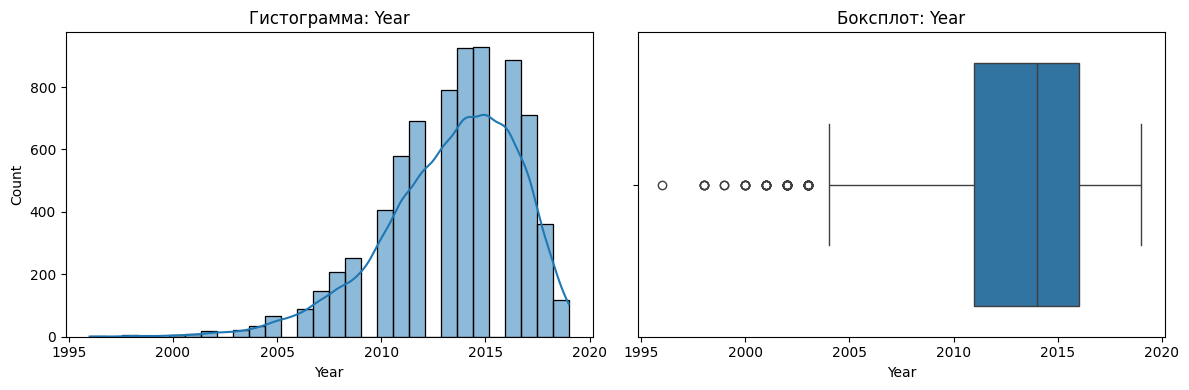

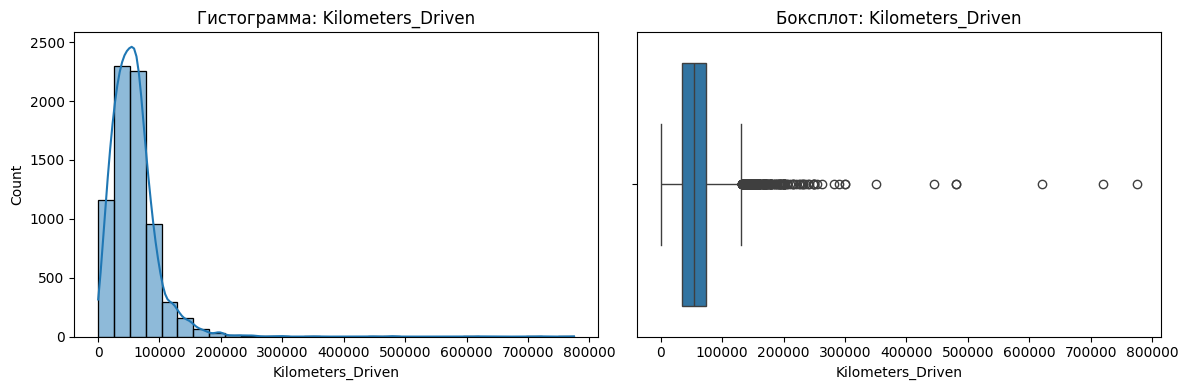

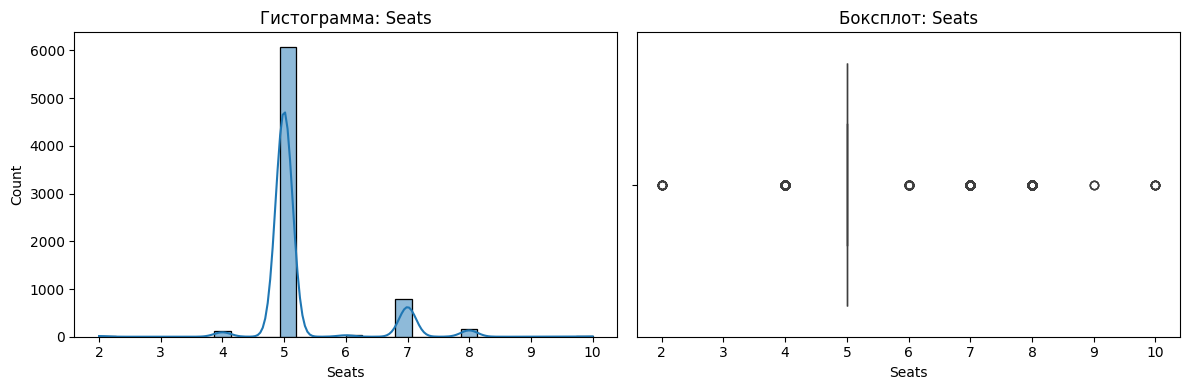

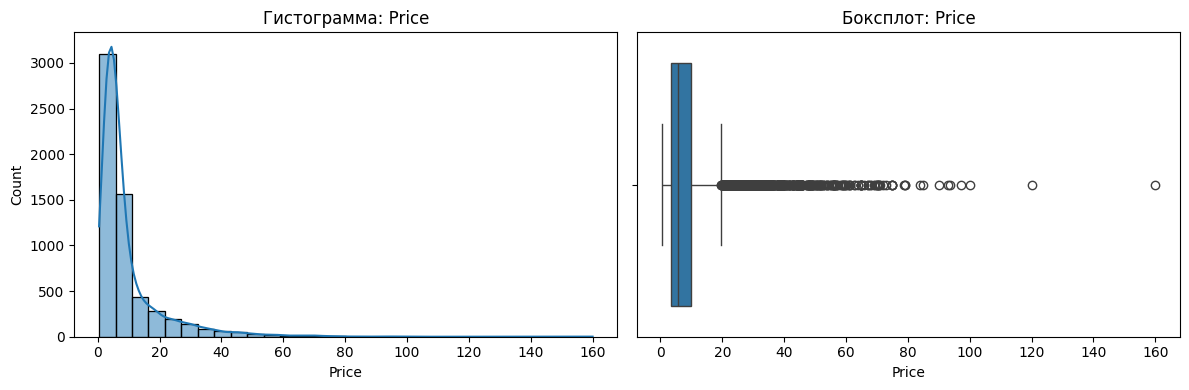

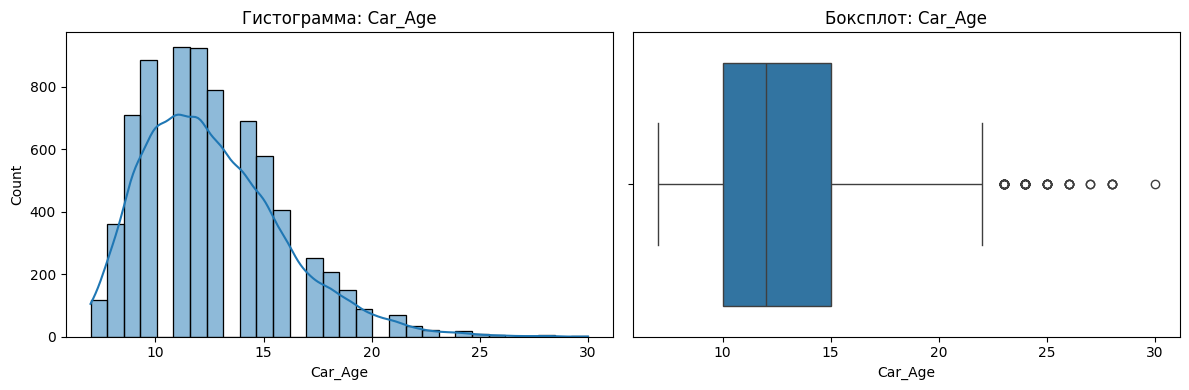

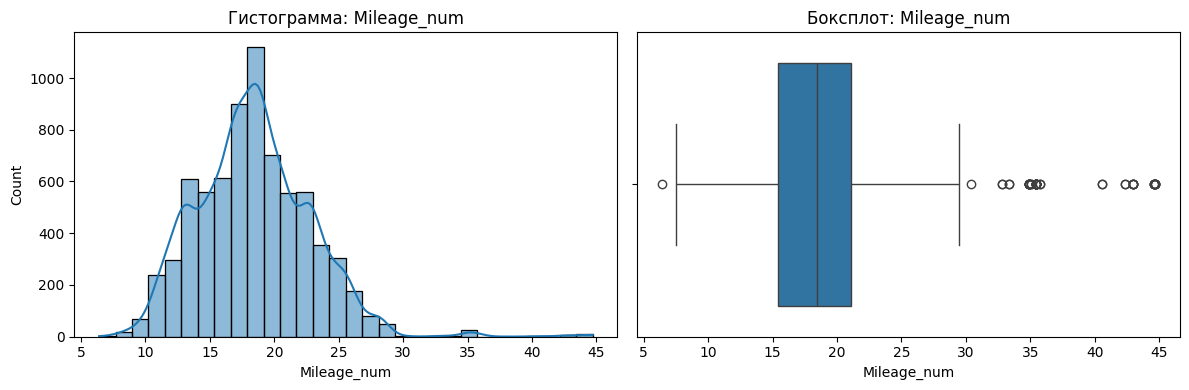

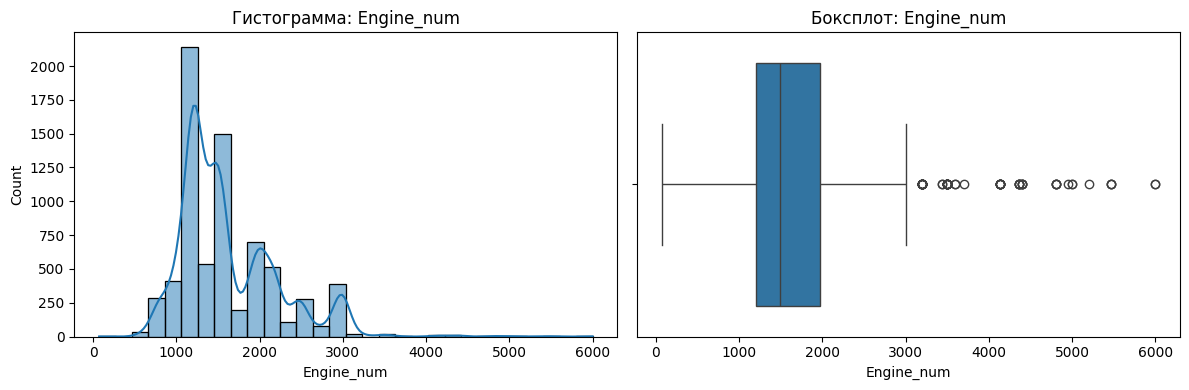

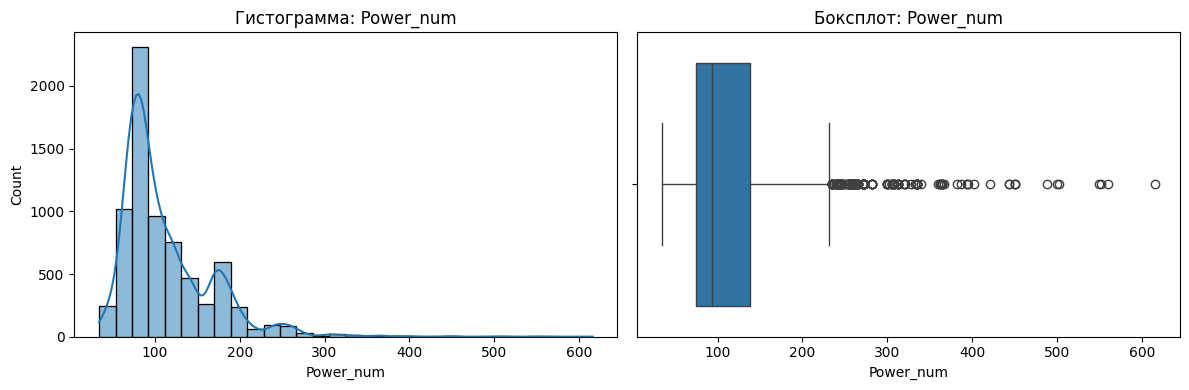

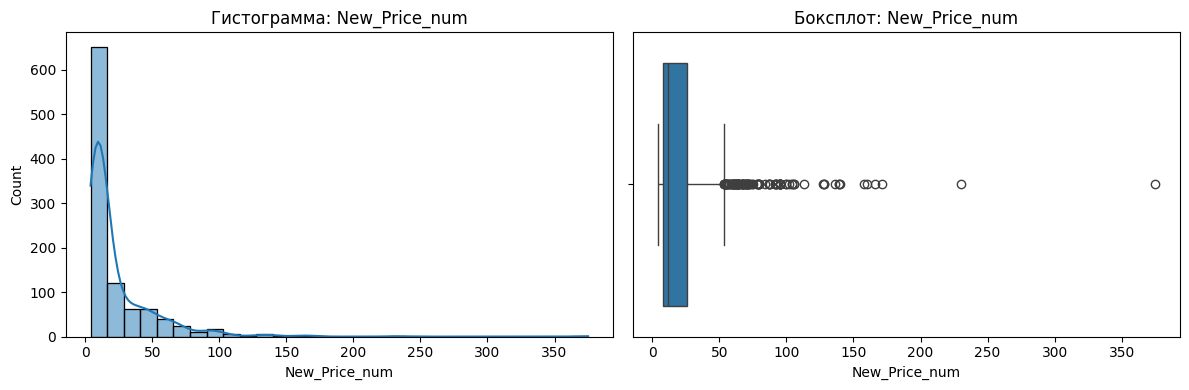

In [ ]:
# Визуализируйте числовые переменные с помощью гистограмм и боксплотов 
# (Синтаксис в файле "EDA - п.3.2")

# 1) Определяем числовые столбцы
num_cols = cars.select_dtypes(include='number').columns.tolist()
print('Числовые столбцы:')
print(num_cols)

# Заметил аномалию на гистограмме для столбца 'Kilometers_Driven' проверил и исправил опечатку. 
# Нашел такую же модельмарку машины такого же года выпуска и за пробег взял ее значение
display(cars.sort_values(by='Kilometers_Driven', ascending=False).head(3))
display(cars[(cars['Brand'] == 'BMW') & (cars['Model'] == 'X5xDrive') & (cars['Year'] == 2017)])
cars.loc[2328, 'Kilometers_Driven'] = 21000
display(cars[(cars['Brand'] == 'BMW') & (cars['Model'] == 'X5xDrive') & (cars['Year'] == 2017)])

# 2) Гистограмма + боксплот для каждого числового столбца
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(cars[col].dropna(), bins=30, kde=True, ax=axes[0])
    axes[0].set_title(f'Гистограмма: {col}')

    sns.boxplot(x=cars[col].dropna(), ax=axes[1])
    axes[1].set_title(f'Боксплот: {col}')

    plt.tight_layout()
    plt.show()

##### <b><font color='teal'>Задание 3</font></b>
Выведите информацию о самых крайних выбросах всех столбцов. Проанализируйте, есть ли среди них ошибки ввода. Ликвидируйте их любым способом, учитывающим специфику данных

In [ ]:
# На основании боксплотов посмотрите крайние выбросы, и выведите строки по этим таблицам
num_cols = cars.select_dtypes(include='number').columns

for col in num_cols:
    q1 = cars[col].quantile(0.25)
    q3 = cars[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    outliers = cars[(cars[col] < low) | (cars[col] > high)]
    print(f'\n{col}: выбросов = {len(outliers)}')
    if len(outliers) > 0:
        display(outliers.sort_values(col, ascending=False).head(5))


Year: выбросов = 58


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,...,Brand,Model,Mileage_num,Mileage_units,Engine_num,Engine_units,Power_num,Power_units,New_Price_num,New_Price_units
911,Kochi,2003,61495,Petrol,Manual,Third,17.3 kmpl,993 CC,60 bhp,5.0,...,Maruti,ZenVXI,17.3,kmpl,993.0,CC,60.0,bhp,NaN,NaN
364,Kolkata,2003,65000,Petrol,Manual,First,17.3 kmpl,993 CC,60 bhp,5.0,...,Maruti,ZenLX,17.3,kmpl,993.0,CC,60.0,bhp,NaN,NaN
1221,Chennai,2003,80000,Diesel,Manual,Third,12.8 kmpl,1489 CC,35.5 bhp,5.0,...,Ambassador,ClassicNova,12.8,kmpl,1489.0,CC,35.5,bhp,NaN,NaN
3854,Chennai,2003,44200,Petrol,Manual,Second,11.7 kmpl,1997 CC,134 bhp,5.0,...,Hyundai,SonataGOLD,11.7,kmpl,1997.0,CC,134.0,bhp,NaN,NaN
2524,Chennai,2003,101000,Petrol,Manual,Third,17.3 kmpl,1061 CC,64 bhp,5.0,...,Maruti,WagonR,17.3,kmpl,1061.0,CC,64.0,bhp,NaN,NaN



Kilometers_Driven: выбросов = 257


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,...,Brand,Model,Mileage_num,Mileage_units,Engine_num,Engine_units,Power_num,Power_units,New_Price_num,New_Price_units
340,Kolkata,2013,775000,Diesel,Automatic,First,19.3 kmpl,1968 CC,141 bhp,5.0,...,Skoda,OctaviaAmbition,19.30,kmpl,1968.0,CC,141.00,bhp,NaN,NaN
1860,Chennai,2013,720000,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.0,...,Volkswagen,VentoDiesel,20.54,kmpl,1598.0,CC,103.60,bhp,NaN,NaN
358,Chennai,2009,620000,Petrol,Manual,First,20.36 kmpl,1197 CC,78.9 bhp,5.0,...,Hyundai,i10Magna,20.36,kmpl,1197.0,CC,78.90,bhp,NaN,NaN
2823,Chennai,2015,480000,Diesel,Automatic,First,16.96 kmpl,1968 CC,138.03 bhp,5.0,...,Volkswagen,Jetta2013-2015,16.96,kmpl,1968.0,CC,138.03,bhp,NaN,NaN
3092,Kolkata,2015,480000,Petrol,Manual,First,17.4 kmpl,1497 CC,117.3 bhp,5.0,...,Honda,Cityi,17.40,kmpl,1497.0,CC,117.30,bhp,NaN,NaN



Seats: выбросов = 1154


...

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,...,Brand,Model,Mileage_num,Mileage_units,Engine_num,Engine_units,Power_num,Power_units,New_Price_num,New_Price_units
5521,Hyderabad,2006,48000,Petrol,Automatic,First,8.6 kmpl,5998 CC,552 bhp,4.0,...,Bentley,ContinentalFlying,8.60,kmpl,5998.0,CC,552.0,bhp,NaN,NaN
6354,Bangalore,2008,31200,Petrol,Automatic,Second,10.2 kmpl,5998 CC,616 bhp,5.0,...,Bentley,FlyingSpur,10.20,kmpl,5998.0,CC,616.0,bhp,375.0,Lakh
4691,Bangalore,2014,3000,Petrol,Automatic,Second,12.0 kmpl,5461 CC,421 bhp,2.0,...,Mercedes-Benz,SLK-Class55,12.00,kmpl,5461.0,CC,421.0,bhp,NaN,NaN
152,Kolkata,2010,35277,Petrol,Automatic,First,7.81 kmpl,5461 CC,362.9 bhp,5.0,...,Mercedes-Benz,SClass,7.81,kmpl,5461.0,CC,362.9,bhp,NaN,NaN
4722,Kolkata,2010,35000,Petrol,Automatic,First,8.1 kmpl,5461 CC,387.3 bhp,2.0,...,Mercedes-Benz,SL-ClassSL,8.10,kmpl,5461.0,CC,387.3,bhp,NaN,NaN



Power_num: выбросов = 273


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,...,Brand,Model,Mileage_num,Mileage_units,Engine_num,Engine_units,Power_num,Power_units,New_Price_num,New_Price_units
6354,Bangalore,2008,31200,Petrol,Automatic,Second,10.2 kmpl,5998 CC,616 bhp,5.0,...,Bentley,FlyingSpur,10.2,kmpl,5998.0,CC,616.0,bhp,375.0,Lakh
5781,Delhi,2011,6500,Petrol,Automatic,Third,6.4 kmpl,5204 CC,560 bhp,2.0,...,Lamborghini,GallardoCoupe,6.4,kmpl,5204.0,CC,560.0,bhp,NaN,NaN
5521,Hyderabad,2006,48000,Petrol,Automatic,First,8.6 kmpl,5998 CC,552 bhp,4.0,...,Bentley,ContinentalFlying,8.6,kmpl,5998.0,CC,552.0,bhp,NaN,NaN
2100,Mumbai,2010,35000,Petrol,Automatic,Second,11.9 kmpl,4806 CC,550 bhp,5.0,...,Porsche,CayenneTurbo,11.9,kmpl,4806.0,CC,550.0,bhp,NaN,NaN
5088,Coimbatore,2011,43686,Petrol,Automatic,First,10.5 kmpl,5000 CC,503 bhp,4.0,...,Jaguar,XJ5.0,10.5,kmpl,5000.0,CC,503.0,bhp,NaN,NaN



New_Price_num: выбросов = 108


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,...,Brand,Model,Mileage_num,Mileage_units,Engine_num,Engine_units,Power_num,Power_units,New_Price_num,New_Price_units
6354,Bangalore,2008,31200,Petrol,Automatic,Second,10.2 kmpl,5998 CC,616 bhp,5.0,...,Bentley,FlyingSpur,10.20,kmpl,5998.0,CC,616.00,bhp,375.0,Lakh
4079,Hyderabad,2017,25000,Diesel,Automatic,First,13.33 kmpl,2993 CC,255 bhp,5.0,...,Land Rover,RoverRange,13.33,kmpl,2993.0,CC,255.00,bhp,230.0,Lakh
4778,Bangalore,2011,47140,Diesel,Automatic,Second,13.5 kmpl,2925 CC,281.61 bhp,5.0,...,Mercedes-Benz,S-ClassS,13.50,kmpl,2925.0,CC,281.61,bhp,171.0,Lakh
3199,Kolkata,2012,41100,Diesel,Automatic,First,16.77 kmpl,2993 CC,261.49 bhp,5.0,...,BMW,7Series,16.77,kmpl,2993.0,CC,261.49,bhp,166.0,Lakh
3752,Kochi,2015,38467,Diesel,Automatic,First,12.65 kmpl,2993 CC,255 bhp,5.0,...,Land Rover,RoverRange,12.65,kmpl,2993.0,CC,255.00,bhp,160.0,Lakh


In [ ]:
# Примите решение по каждому выбросу и реализуйте это
# Добавьте комментарий по вашему решению

# Мое решение:
# 1) Исправил явную опечатку в пробеге: BMW X5xDrive 2017 (6_500_000 -> 21_000).
# 2) Все остальные выбросы в числовых столбцах не удалял, т.к. они в полне правдоподнобные
#  

display(cars.sort_values(by='Price', ascending=False).head(3))

NameError: name 'cars' is not defined